### **Combine Data Sets**

In [ ]:
!pip install missingno -q

In [ ]:
# Library to connect Google Drive
from google.colab import drive
import pandas as pd
import os
import glob

# Library for Machine Learning process
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Library for EDA - visual analysing
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Library for saving model
import joblib

In [ ]:
# Connect to Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/CETM46 - Assignment 2/folder_data_6months
!ls

/content/drive/MyDrive/CETM46 - Assignment 2/folder_data_6months
420JourneyDataExtract14May2025-31May2025.csv
421JourneyDataExtract01Jun2025-15Jun2025.csv
422JourneyDataExtract15Jun2025-30Jun2025.csv
423JourneyDataExtract01Jul2025-15Jul2025.csv
424JourneyDataExtract16Jul2025-31Jul2025.csv
425JourneyDataExtract01Aug2025-15Aug2025.csv
426JourneyDataExtract16Aug2025-31Aug2025.csv
427JourneyDataExtract01Sep2025-15Sep2025.csv
428JourneyDataExtract16Sep2025-30Sep2025.csv
429JourneyDataExtract01Oct2025-15Oct2025.csv
430JourneyDataExtract16Oct2025-31Oct2025.csv
431JourneyDataExtract01Nov2025-15Nov2025.csv
432JourneyDataExtract16Nov2025-30Nov2025.csv
433JourneyDataExtract01Dec2025-15Dec2025.csv
434JourneyDataExtract16Dec2025-31Dec2025.csv


In [ ]:
# Combine every single file into an unified file
path = "/content/drive/MyDrive/CETM46 - Assignment 2/folder_data_6months"
all_files = glob.glob(os.path.join(path, "4*.csv"))
concatnated_result = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
print(f"The number of data after concatnating is {len(concatnated_result)}.")


The number of data after concatnating is 5985362.


### **Data Exploring and Pre-processing**

In [ ]:
concatnated_result.head()

,Number,Start date,Start station number,End date,End station,End station number,Start station,Bike number,Bike model,Total duration,Total duration (ms)
0,154763892,2025-12-31 23:59,1096,2026-01-01 01:26,"London Street, Paddington",300079.0,"Bayswater Road, Hyde Park",56321,CLASSIC,1h 27m 29s,5249249.0
1,154763893,2025-12-31 23:59,1096,2026-01-01 00:20,"Triangle Car Park, Hyde Park",1088.0,"Bayswater Road, Hyde Park",20939,CLASSIC,20m 52s,1252988.0
2,154763894,2025-12-31 23:59,2683,2026-01-01 00:58,"Cephas Street, Bethnal Green",200073.0,"Millbank Tower, Pimlico",59614,CLASSIC,58m 30s,3510003.0
3,154763891,2025-12-31 23:58,200048,2026-01-01 00:27,"Gloucester Terrace, Bayswater",1173.0,"Page Street, Westminster",62957,PBSC_EBIKE,28m 45s,1725687.0
4,154763887,2025-12-31 23:57,1062,2026-01-01 02:01,"Salmon Lane, Limehouse",200147.0,"Braham Street, Aldgate",63135,PBSC_EBIKE,2h 3m 50s,7430544.0


In [ ]:
concatnated_result.tail()

,Number,Start date,Start station number,End date,End station,End station number,Start station,Bike number,Bike model,Total duration,Total duration (ms)
5985357,148598723,2025-05-15 00:00,1081,2025-05-15 00:15,"Whitehall Place, Strand",1151.0,"Liverpool Road (N1 Centre), Angel",53061,CLASSIC,14m 42s,882227.0
5985358,148598724,2025-05-15 00:00,300020,2025-05-15 00:06,"Everington Street, Fulham",300028.0,"West Kensington Station, West Kensington",58926,CLASSIC,5m 48s,348380.0
5985359,148598725,2025-05-15 00:00,1162,2025-05-15 00:05,"Penfold Street, Marylebone",10625.0,"Dorset Square, Marylebone",52278,CLASSIC,4m 4s,244456.0
5985360,148598726,2025-05-15 00:00,300232,2025-05-15 00:22,"Queensway, Kensington Gardens",1150.0,"Riverlight South, Nine Elms",63255,PBSC_EBIKE,21m 15s,1275945.0
5985361,148598727,2025-05-15 00:01,1077,2025-05-15 00:06,"Harford Street, Mile End",200102.0,"Royal London Hospital, Whitechapel",53447,CLASSIC,4m 59s,299917.0


In [ ]:
concatnated_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5985362 entries, 0 to 5985361
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Number                int64  
 1   Start date            object 
 2   Start station number  int64  
 3   End date              object 
 4   End station           object 
 5   End station number    float64
 6   Start station         object 
 7   Bike number           int64  
 8   Bike model            object 
 9   Total duration        object 
 10  Total duration (ms)   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 502.3+ MB


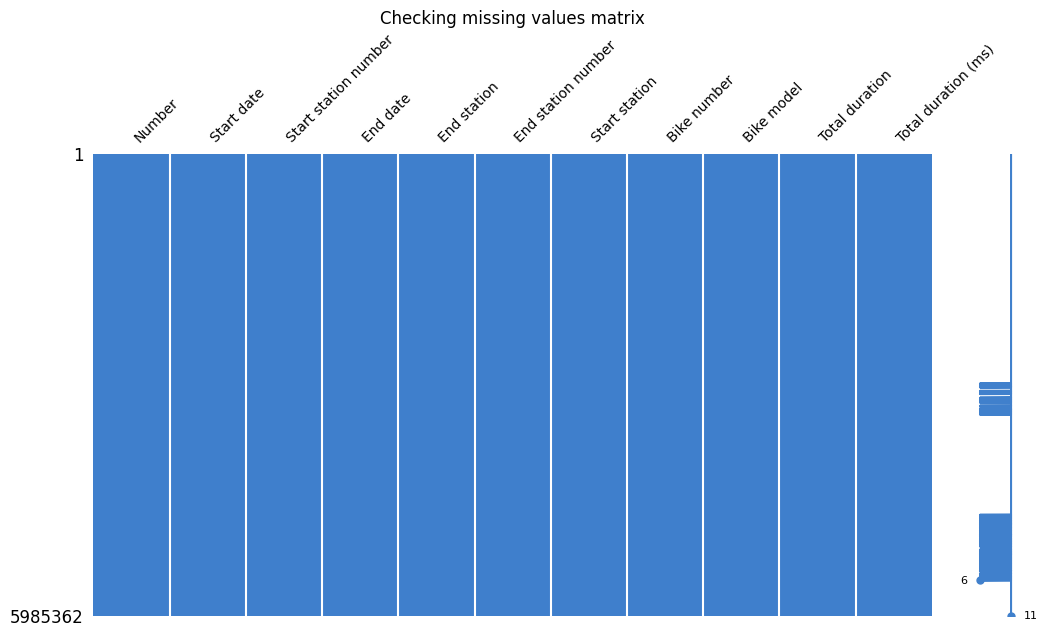

In [ ]:
msno.matrix(concatnated_result, figsize=(12, 6),
            fontsize=10, color= (0.25, 0.5, 0.8))
plt.title('Checking missing values matrix')
plt.show()

In [ ]:
# Count the number or unique bike
unique_bike = concatnated_result['Bike number'].nunique()
print(f"The number of unique bike is {unique_bike}.")

The number of unique bike is 13390.


In [ ]:
# Count the over 24h outlier
outliers_over_24h = concatnated_result[concatnated_result['Total duration (ms)'] > 86400000]
count_outliers_24h = len(outliers_over_24h)
print(f"The number of outliers over 24 hours: {count_outliers_24h}.")

The number of outliers over 24 hours: 4391.


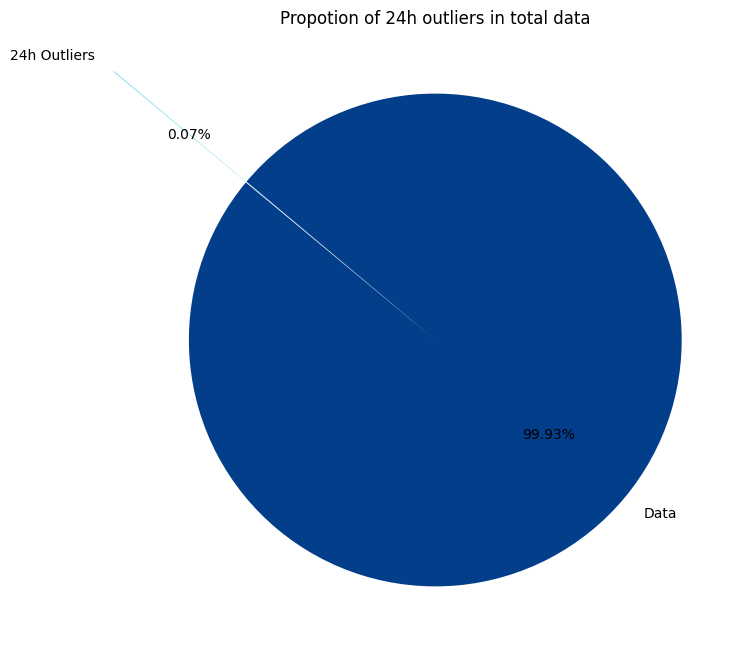

In [ ]:
# Pie chart to compare "24h outlier vs total data"
total_data = len(concatnated_result)
total_24h_outliers = count_outliers_24h

normal_data_count_1 = total_data - total_24h_outliers

labels = ['24h Outliers', 'Data']
sizes = [total_24h_outliers, normal_data_count_1]

color = ['#90e0ef', '#023e8a']

plt.figure(figsize=(8, 8))
explode = (0.7, 0) if count_outliers_24h > 0 else (0, 0)
plt.pie(sizes, explode=explode, labels=labels,
        colors=color, autopct='%1.2f%%', startangle=140)

plt.title("Propotion of 24h outliers in total data")
plt.show()

In [ ]:
# Count the "ghost" bike under 1 minute
outliers_under_1m = concatnated_result[concatnated_result['Total duration (ms)'] < 60000]
count_outliers_1m = len(outliers_under_1m)
print(f"The number of outliers under 1 minute: {count_outliers_1m}.")

The number of outliers under 1 minute: 47569.


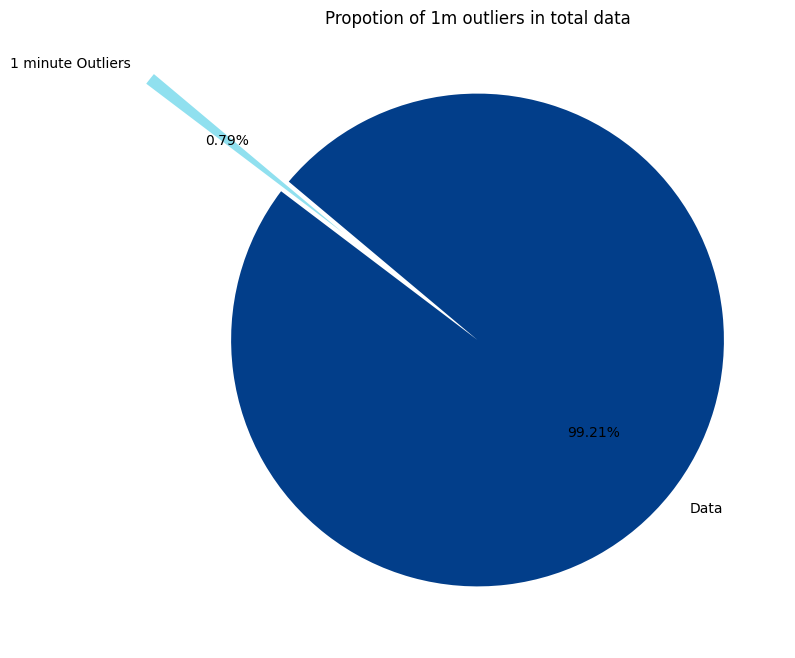

In [ ]:
# Pie chart to compare "1m outlier vs total data"
total_data = len(concatnated_result)
total_1m_outliers = count_outliers_1m

normal_data_count_2 = total_data - total_1m_outliers

labels = ['1 minute Outliers', 'Data']
sizes = [total_1m_outliers, normal_data_count_2]

color = ['#90e0ef', '#023e8a']

plt.figure(figsize=(8, 8))
explode = (0.7, 0) if count_outliers_1m > 0 else (0, 0)
plt.pie(sizes, explode=explode, labels=labels,
        colors=color, autopct='%1.2f%%', startangle=140)

plt.title("Propotion of 1m outliers in total data")
plt.show()

In [ ]:
# Adjust attributes name
concatnated_result['bike_number'] = concatnated_result['Bike number']
concatnated_result['bike_model'] = concatnated_result['Bike model']
concatnated_result['start_date'] = concatnated_result['Start date']

In [ ]:
# Transfer 'duration' unit from Milisecond to Hour
concatnated_result['duration_hour'] = concatnated_result['Total duration (ms)'] / (1000*3600)

In [ ]:
# Statistical computation of "duration_hour" variable
descriptive_stat_data = concatnated_result['duration_hour'].describe()
descriptive_stat_data

,duration_hour
count,5.985178e+06
mean,4.591978e-01
std,1.289130e+01
min,1.025000e-04
25%,1.315900e-01
50%,2.268650e-01
75%,3.701314e-01
max,5.023920e+03


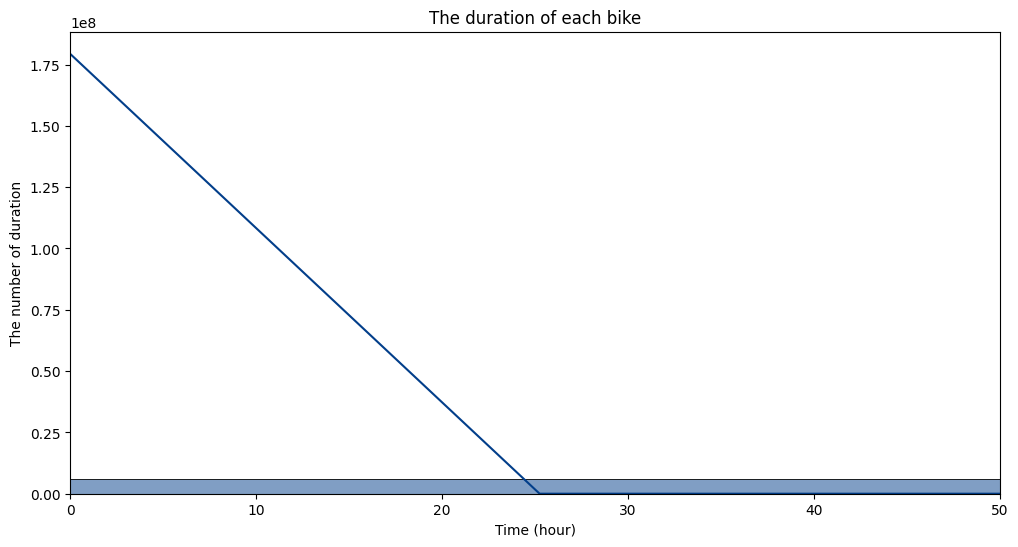

In [ ]:

plt.figure(figsize=(12, 6))
sns.histplot(concatnated_result['duration_hour'],
             bins=100, kde=True, color='#023e8a')
plt.title('The duration of each bike')
plt.xlabel('Time (hour)')
plt.ylabel('The number of duration')

plt.xlim(0, 50)
plt.show()

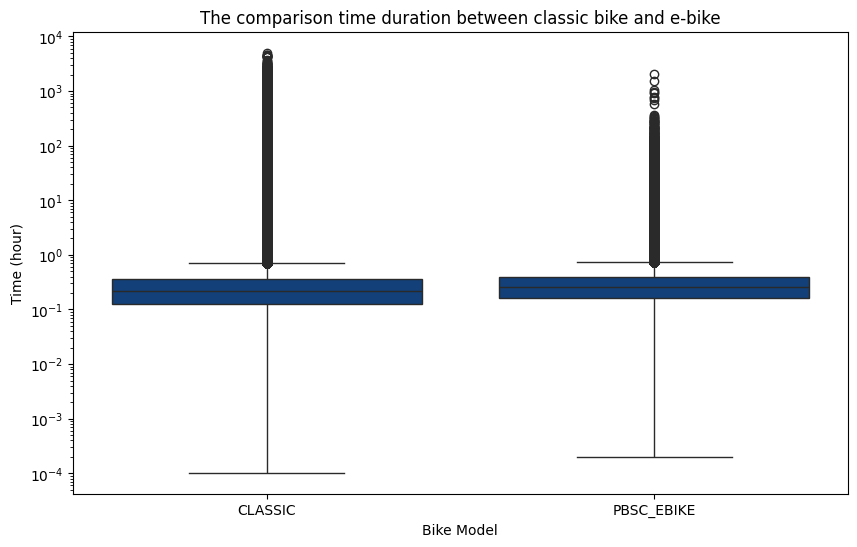

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bike_model', y='duration_hour', data=concatnated_result, color='#023e8a')
plt.xlabel('Bike Model')
plt.ylabel('Time (hour)')
plt.yscale('log') # Significant outliers
plt.title('The comparison time duration between classic bike and e-bike')
plt.show()

/tmp/ipykernel_9436/2346825807.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


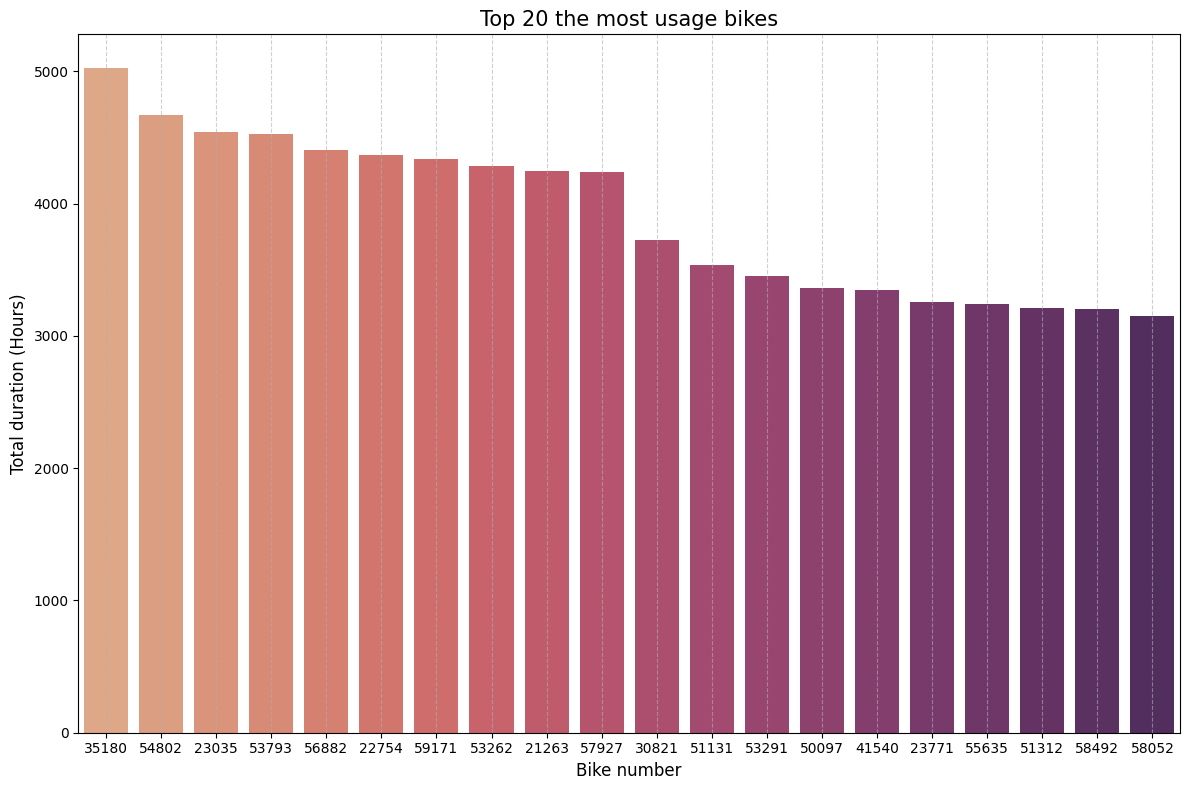

In [ ]:
# Aggregate the bike number and the total of duration time
bike_usage = concatnated_result.groupby('bike_number')['duration_hour'].sum().reset_index()

# Rank 20 the most usage bikes
most_bikes = bike_usage.sort_values(by='duration_hour', ascending=False).head(20)

# Transfer "bike_number" into string, avoid ordinal
most_bikes['bike_number'] = most_bikes['bike_number'].astype(str)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=most_bikes,
    y='duration_hour',
    x='bike_number',
    palette='flare'
)

plt.title('Top 20 the most usage bikes', fontsize=15)
plt.ylabel('Total duration (Hours)', fontsize=12)
plt.xlabel('Bike number', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
#plt.savefig('top_bike_usage_raw.png')
plt.show()

/tmp/ipykernel_9436/3650202826.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


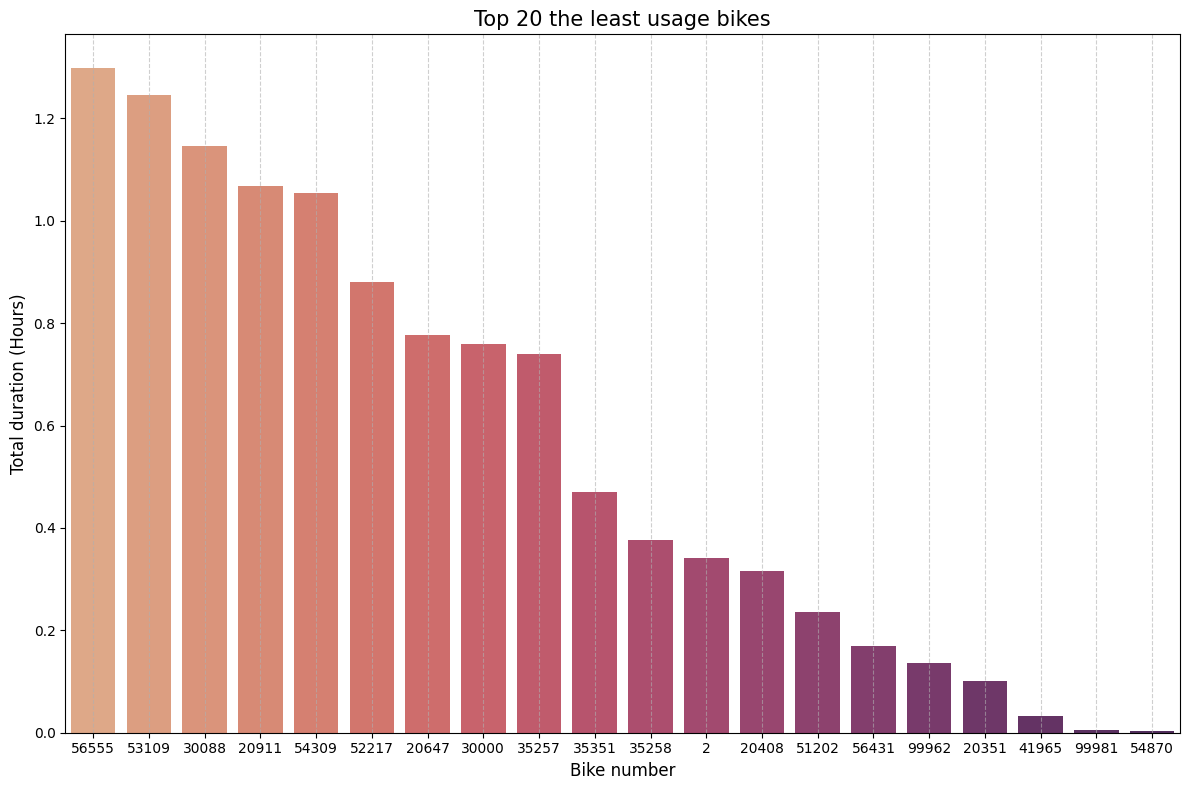

In [ ]:
# Aggregate the bike number and the total of duration time
bike_usage = concatnated_result.groupby('bike_number')['duration_hour'].sum().reset_index()

# Rank 20 the most usage bikes
least_bikes = bike_usage.sort_values(by='duration_hour', ascending=False).tail(20)

# Arrange them as ordinary
least_bikes['bike_number'] = least_bikes['bike_number'].astype(str)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=least_bikes,
    y='duration_hour',
    x='bike_number',
    palette='flare'
)

plt.title('Top 20 the least usage bikes', fontsize=15)
plt.ylabel('Total duration (Hours)', fontsize=12)
plt.xlabel('Bike number', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
#plt.savefig('top_bike_usage_raw.png')
plt.show()

In [ ]:
# Case 1: Unusual user behaviour: duration under 1 minute
short_trips = concatnated_result[concatnated_result['Total duration (ms)'] < 60000].copy()

#Case 2: Stolen or system errors: duration over 24 hours
long_trips = concatnated_result[concatnated_result['Total duration (ms)'] > 86400000].copy()

# Filter noise records under 1 minute
clean_data = concatnated_result[
    (concatnated_result['Total duration (ms)'] > 60000) &
     (concatnated_result['Total duration (ms)'] < 86400000)].copy()

# Datetime type
clean_data['start_date'] = pd.to_datetime(concatnated_result['start_date'])

latest_time_system = clean_data['start_date'].max()


bike_information = clean_data[['bike_number', 'duration_hour', 'bike_model', 'start_date']]

bike_information

,bike_number,duration_hour,bike_model,start_date
0,56321,1.458125,CLASSIC,2025-12-31 23:59:00
1,20939,0.348052,CLASSIC,2025-12-31 23:59:00
2,59614,0.975001,CLASSIC,2025-12-31 23:59:00
3,62957,0.479357,PBSC_EBIKE,2025-12-31 23:58:00
4,63135,2.064040,PBSC_EBIKE,2025-12-31 23:57:00
...,...,...,...,...
5985357,53061,0.245063,CLASSIC,2025-05-15 00:00:00
5985358,58926,0.096772,CLASSIC,2025-05-15 00:00:00
5985359,52278,0.067904,CLASSIC,2025-05-15 00:00:00
5985360,63255,0.354429,PBSC_EBIKE,2025-05-15 00:00:00


In [ ]:
# Group all attributes based on 'bike_number'
bike_health = bike_information.groupby(['bike_number', 'bike_model']).agg(
    total_trips = ('bike_number', 'count'),
    total_hours = ('duration_hour', 'sum'),
    avg_trip_duration = ('duration_hour', 'mean'),
    last_active_date_per_bike = ('start_date', 'max')
).reset_index()

# Compute the last active day to check bike situation
bike_health['latest_active'] = (latest_time_system - bike_health['last_active_date_per_bike']).dt.days

# Survival labeling based on total hours > 200 hours
bike_health['need_maintenance'] = (bike_health['total_hours'] >=200).astype(int)

bike_health.sort_values(by='total_hours', ascending=False).head()

,bike_number,bike_model,total_trips,total_hours,avg_trip_duration,last_active_date_per_bike,latest_active,need_maintenance
10186,58714,CLASSIC,952,314.971016,0.330852,2025-12-30 13:49:00,1,1
8676,56815,CLASSIC,918,298.169805,0.324804,2025-12-31 17:37:00,0,1
9939,58315,CLASSIC,906,296.721841,0.327508,2025-12-31 19:28:00,0,1
9776,58063,CLASSIC,877,296.399629,0.337970,2025-12-25 21:52:00,6,1
6158,53880,CLASSIC,873,295.103169,0.338033,2025-12-31 21:35:00,0,1


In [ ]:
bike_health

,bike_number,bike_model,total_trips,total_hours,avg_trip_duration,last_active_date_per_bike,latest_active,need_maintenance
0,2,CLASSIC,2,0.341527,0.170763,2025-06-06 17:46:00,208,0
1,4,CLASSIC,363,132.314604,0.364503,2025-12-21 01:50:00,10,0
2,6,CLASSIC,367,103.956474,0.283260,2025-12-28 16:20:00,3,0
3,9,CLASSIC,354,116.667413,0.329569,2025-11-04 00:03:00,57,0
4,11204,CLASSIC,9,1.944094,0.216010,2025-05-21 10:40:00,224,0
...,...,...,...,...,...,...,...,...
13383,90903,CLASSIC,859,239.017713,0.278251,2025-12-31 13:53:00,0,1
13384,90904,CLASSIC,734,232.415058,0.316642,2025-12-31 21:19:00,0,1
13385,90905,CLASSIC,780,212.981089,0.273053,2025-11-17 17:32:00,44,1
13386,90906,CLASSIC,684,218.667031,0.319689,2025-12-30 14:04:00,1,1


In [ ]:
# The number of values 1-0
maintenance_counts = bike_health['need_maintenance'].value_counts()
maintenance_counts

,count
need_maintenance,
0,12284
1,1104


In [ ]:
# Need maintenance bike percentage
maintenance_pct = bike_health['need_maintenance'].value_counts(normalize=True) * 100
maintenance_pct

# Imbalanced data

,proportion
need_maintenance,
0,91.753809
1,8.246191


In [ ]:
# Compare the total hours between bike types based on total trips
print("Top Classic Bikes:")
print(bike_health[bike_health['bike_model'] == 'CLASSIC'].sort_values(by='total_hours', ascending=False).head())

print("Top E-Bikes:")
print(bike_health[bike_health['bike_model'] == 'PBSC_EBIKE'].sort_values(by='total_hours', ascending=False).head())

Top Classic Bikes:
       bike_number bike_model  total_trips  total_hours  avg_trip_duration  \
10186        58714    CLASSIC          952   314.971016           0.330852   
8676         56815    CLASSIC          918   298.169805           0.324804   
9939         58315    CLASSIC          906   296.721841           0.327508   
9776         58063    CLASSIC          877   296.399629           0.337970   
6158         53880    CLASSIC          873   295.103169           0.338033   

      last_active_date_per_bike  latest_active  need_maintenance  
10186       2025-12-30 13:49:00              1                 1  
8676        2025-12-31 17:37:00              0                 1  
9939        2025-12-31 19:28:00              0                 1  
9776        2025-12-25 21:52:00              6                 1  
6158        2025-12-31 21:35:00              0                 1  
Top E-Bikes:
       bike_number  bike_model  total_trips  total_hours  avg_trip_duration  \
11888        62231

### **Modelling**

In [ ]:
# Encode 'bike_model' with Classic (0) & E-Bike (1)
le = LabelEncoder()
bike_health['bike_model'] = le.fit_transform(bike_health['bike_model'])

# Feature selection
features = ['total_trips', 'avg_trip_duration', 'latest_active', 'bike_model']
X = bike_health[features]
y = bike_health['need_maintenance']

In [ ]:
# Train 80% - Test 20% split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) # 'stratify' keep value '1' of need maintenance in both sets

# Using k-fold to take validation set for training
kfold_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

***1. Logistic Regression***

In [ ]:
logreg_model = Pipeline([('scaler', StandardScaler()),
                          ('lr', LogisticRegression(class_weight='balanced',
                                                    random_state=42,
                                                    max_iter=1000))])

logreg_val = cross_val_score(logreg_model, X_train, y_train, cv=kfold_val, scoring='f1')

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2457
           1       0.78      1.00      0.88       221

    accuracy                           0.98      2678
   macro avg       0.89      0.99      0.93      2678
weighted avg       0.98      0.98      0.98      2678



***2. Random Forest***

In [ ]:
randomfr_model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                        random_state=42, n_jobs=-1)

cross_val = cross_val_score(randomfr_model, X_train, y_train, cv=kfold_val, scoring='f1')

randomfr_model.fit(X_train, y_train)

y_pred = randomfr_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2457
           1       0.99      0.98      0.98       221

    accuracy                           1.00      2678
   macro avg       0.99      0.99      0.99      2678
weighted avg       1.00      1.00      1.00      2678



/tmp/ipykernel_12916/2574570860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


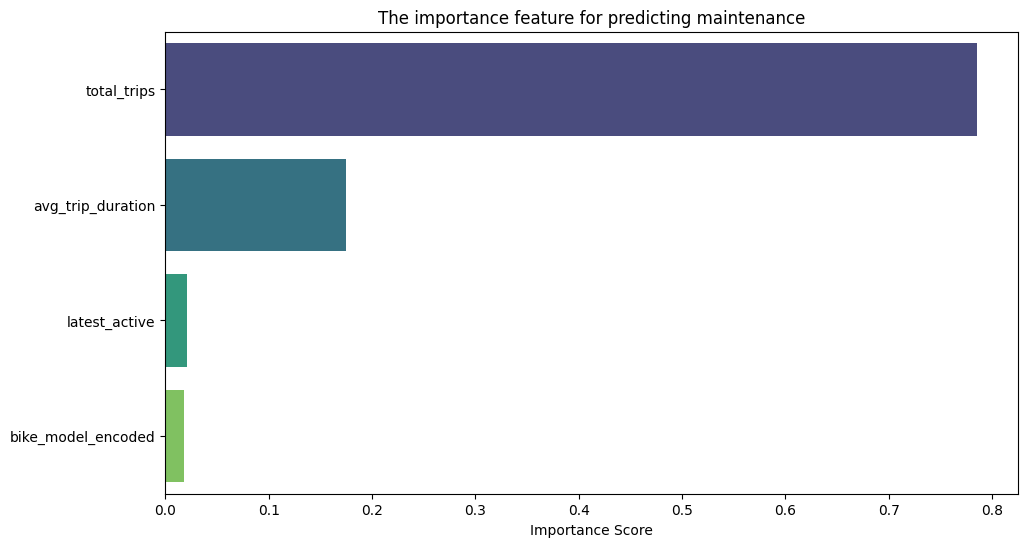

In [ ]:
# Ranking the most important variable in the best model
importances = randomfr_model.feature_importances_
feature_names = ['total_trips', 'avg_trip_duration', 'latest_active', 'bike_model_encoded']

plt.figure(figsize=(11, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('The importance feature for predicting maintenance')
plt.xlabel('Importance Score')
plt.show()

***3. XGBoost***

In [ ]:
y_train.value_counts()

,count
need_maintenance,
0,9827
1,883


In [ ]:
# Handle imbalanced data with 'scale_pos_weight', consider ratio
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                          scale_pos_weight=ratio, random_state=42,
                          use_label_encoder=False, eval_metric='logloss')

xgb_val = cross_val_score(xgb_model, X_train, y_train, cv=kfold_val, scoring='f1')

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:46:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:46:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:46:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:46:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2457
           1       0.93      1.00      0.97       221

    accuracy                           0.99      2678
   macro avg       0.97      1.00      0.98      2678
weighted avg       0.99      0.99      0.99      2678



In [ ]:
# Save model and use in streamlit
import joblib

# Random Forest Model
joblib.dump(randomfr_model, 'maintenance_model.pkl')

# Encoded code
joblib.dump(le, 'bike_model_encoder.pkl')

# Anomaly cases
long_trips.to_csv('anomaly_long_trips.csv', index=False)
short_trips.to_csv('anomaly_short_trips.csv', index=False)

print("Complete download")

Complete download


### **Data baseline**

In [ ]:
# Combine every single file into an unified file
path_baseline = "/content/drive/MyDrive/CETM46 - Assignment 2/data_base_line"
all_files_baseline = glob.glob(os.path.join(path_baseline, "*.csv"))
concatnated_baseline_result = pd.concat((pd.read_csv(f) for f in all_files_baseline), ignore_index=True)
print(f"The number of data after concatnating is {len(concatnated_baseline_result)}.")


The number of data after concatnating is 557727.


In [ ]:
baseline_clean = concatnated_baseline_result[
    (concatnated_baseline_result['Total duration (ms)'] > 60000) &
    (concatnated_baseline_result['Total duration (ms)'] <= 86400000)
].copy()

In [ ]:
baseline_clean['duration_hour'] = baseline_clean['Total duration (ms)'] / (1000 * 3600)

In [ ]:
baseline_clean

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms),duration_hour
0,136666627,2024-01-14 23:59,1108,"North Wharf Road, Paddington",2024-01-15 00:06,3423,"Maida Vale, Maida Vale",53020,CLASSIC,6m 47s,407799,0.113278
1,136666625,2024-01-14 23:57,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05,1214,"Kensington Olympia Station, Olympia",54559,CLASSIC,8m 1s,481276,0.133688
2,136666626,2024-01-14 23:57,1090,"Warren Street Station, Euston",2024-01-15 00:02,200005,"New Cavendish Street, Marylebone",52133,CLASSIC,5m 11s,311788,0.086608
3,136666622,2024-01-14 23:56,200058,"Northdown Street, King's Cross",2024-01-15 00:06,2687,"Brick Lane Market, Shoreditch",60341,PBSC_EBIKE,10m 14s,614030,0.170564
4,136666623,2024-01-14 23:56,1052,"Soho Square , Soho",2024-01-15 00:23,1150,"Queensway, Kensington Gardens",55212,CLASSIC,27m 1s,1621583,0.450440
...,...,...,...,...,...,...,...,...,...,...,...,...
557722,136666632,2024-01-15 00:03,959,"Milroy Walk, South Bank",2024-01-15 00:14,1017,"Great Dover Street, The Borough",16206,CLASSIC,11m 50s,710410,0.197336
557723,136666633,2024-01-15 00:03,3471,"Chadwell Street, Angel",2024-01-15 00:34,1112,"Nutford Place, Marylebone",56583,CLASSIC,31m 21s,1881443,0.522623
557724,136666630,2024-01-15 00:01,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05,1121,"Lexham Gardens, Kensington",35397,CLASSIC,3m 50s,230398,0.063999
557725,136666628,2024-01-15 00:00,1220,"Imperial College, Knightsbridge",2024-01-15 00:02,3447,"Gloucester Road (North), Kensington",60506,PBSC_EBIKE,2m 4s,124071,0.034464


In [ ]:
bike_baseline_db = baseline_clean.groupby(['Bike number', 'Bike model']).agg(
    accumulated_hours_past=('duration_hour', 'sum'),
    total_trips_past=('Number', 'count'),
).reset_index()

In [ ]:
bike_baseline_db.rename(columns={'Bike number': 'bike_number',
                                 'Bike model': 'bike_model'}, inplace=True)

In [ ]:
bike_baseline_db

,bike_number,bike_model,accumulated_hours_past,total_trips_past
0,2,CLASSIC,10.073761,42
1,4,CLASSIC,8.701762,48
2,10168,CLASSIC,3.645682,14
3,10169,CLASSIC,3.860265,10
4,10274,CLASSIC,10.431093,40
...,...,...,...,...
11924,61197,PBSC_EBIKE,28.039507,94
11925,61198,PBSC_EBIKE,20.011946,71
11926,61199,PBSC_EBIKE,13.389464,45
11927,61200,PBSC_EBIKE,26.290118,96


In [ ]:
output_filename = 'bike_baseline_db_original.csv'
bike_baseline_db.to_csv(output_filename, index=False)

In [ ]:
from google.colab import files

In [ ]:
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>